In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print(os.listdir('data/'))

['amazon_data.csv', 'keyword_analysis.csv', 'amazon_clean.csv', 'etsy_data1.csv', 'etsy_data2.csv', 'pashmina_trends.csv', 'etsy_clean.csv', 'etsy_data3.csv', 'master_dataset.csv', 'etsy_data4.csv']


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df_trends = pd.read_csv('data/pashmina_trends.csv', skiprows=1)
print(df_trends.head())
print(df_trends.shape)

   2021-06-01  35
0  2021-07-01  73
1  2021-08-01  52
2  2021-09-01  51
3  2021-10-01  56
4  2021-11-01  47
(59, 2)


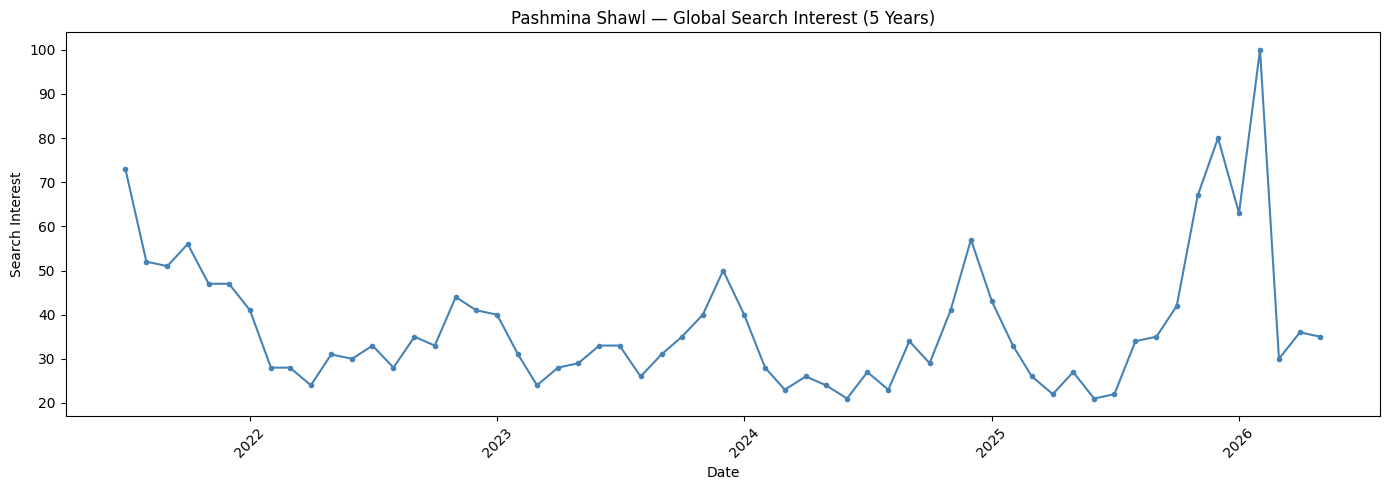

        date  interest
0 2021-07-01        73
1 2021-08-01        52
2 2021-09-01        51
3 2021-10-01        56
4 2021-11-01        47


In [3]:
df_trends.columns = ['date', 'interest']
df_trends['date'] = pd.to_datetime(df_trends['date'])
df_trends['interest'] = pd.to_numeric(df_trends['interest'], errors='coerce')
df_trends = df_trends.dropna()

plt.figure(figsize=(14, 5))
plt.plot(df_trends['date'], df_trends['interest'], color='steelblue', marker='o', markersize=3)
plt.title('Pashmina Shawl — Global Search Interest (5 Years)')
plt.xlabel('Date')
plt.ylabel('Search Interest')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(df_trends.head())

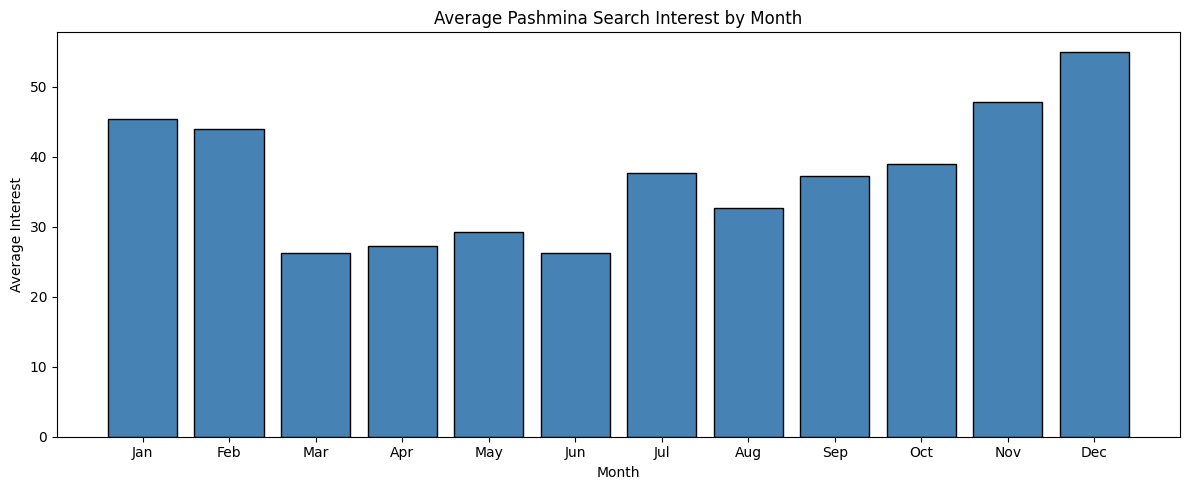

Average interest by month:
Jan: 45.4
Feb: 44.0
Mar: 26.2
Apr: 27.2
May: 29.2
Jun: 26.2
Jul: 37.6
Aug: 32.6
Sep: 37.2
Oct: 39.0
Nov: 47.8
Dec: 55.0


In [4]:
# extract month and year
df_trends['month'] = df_trends['date'].dt.month
df_trends['year'] = df_trends['date'].dt.year

# average interest by month across all years
monthly_avg = df_trends.groupby('month')['interest'].mean()

month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

plt.figure(figsize=(12, 5))
plt.bar(month_names, monthly_avg.values, color='steelblue', edgecolor='black')
plt.title('Average Pashmina Search Interest by Month')
plt.xlabel('Month')
plt.ylabel('Average Interest')
plt.tight_layout()
plt.show()

print("Average interest by month:")
for i, val in enumerate(monthly_avg.values):
    print(f"{month_names[i]}: {val:.1f}")
    

MAE: 12.7 interest points


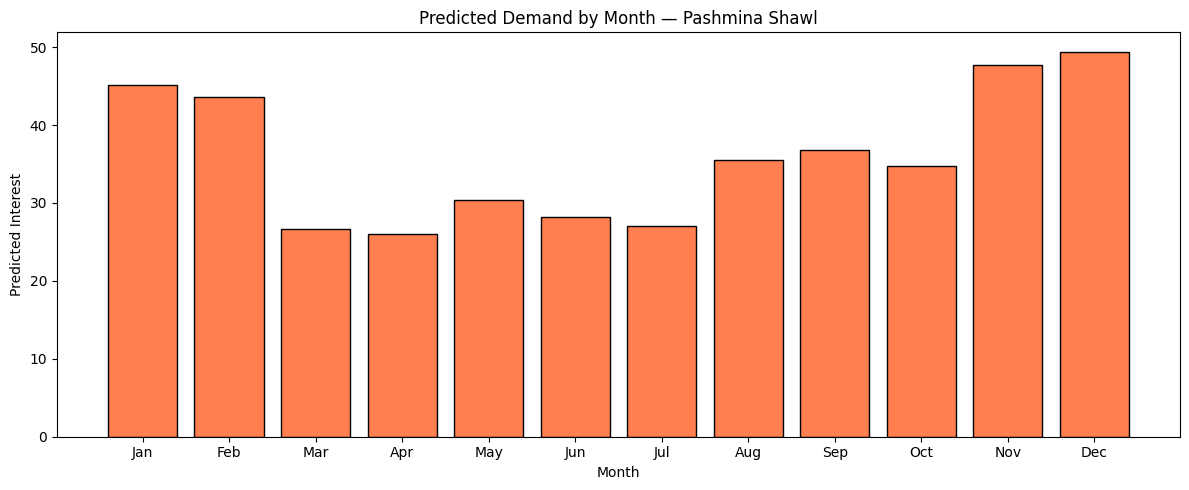

In [5]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

# features: month number + season flags
df_trends['is_winter'] = df_trends['month'].isin([11, 12, 1]).astype(int)
df_trends['is_summer'] = df_trends['month'].isin([3, 4, 5, 6]).astype(int)

X = df_trends[['month', 'is_winter', 'is_summer']]
y = df_trends['interest']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)

print(f"MAE: {mae:.1f} interest points")

# predict demand for all 12 months
months_df = pd.DataFrame({
    'month': range(1, 13),
    'is_winter': [1,0,0,0,0,0,0,0,0,0,1,1],
    'is_summer': [0,0,1,1,1,1,0,0,0,0,0,0]
})

predictions = model.predict(months_df)

plt.figure(figsize=(12, 5))
plt.bar(month_names, predictions, color='coral', edgecolor='black')
plt.title('Predicted Demand by Month — Pashmina Shawl')
plt.xlabel('Month')
plt.ylabel('Predicted Interest')
plt.tight_layout()
plt.show()

In [6]:
def demand_advice(month_num):
    months_input = pd.DataFrame({
        'month': [month_num],
        'is_winter': [1 if month_num in [11, 12, 1] else 0],
        'is_summer': [1 if month_num in [3, 4, 5, 6] else 0]
    })
    
    predicted = model.predict(months_input)[0]
    
    if predicted >= 45:
        advice = "🔥 PEAK SEASON — Run promotions, max stock, push ads"
    elif predicted >= 35:
        advice = "📈 GROWING — Start stocking up, prepare listings"
    elif predicted >= 28:
        advice = "➡️ MODERATE — Maintain presence, no heavy spending"
    else:
        advice = "❄️ LOW SEASON — Focus on new designs, prepare for peak"
    
    print(f"{month_names[month_num-1]}: Predicted Interest = {predicted:.0f} — {advice}")

print("=== ANNUAL BUSINESS CALENDAR ===\n")
for m in range(1, 13):
    demand_advice(m)
    

=== ANNUAL BUSINESS CALENDAR ===

Jan: Predicted Interest = 45 — 🔥 PEAK SEASON — Run promotions, max stock, push ads
Feb: Predicted Interest = 44 — 📈 GROWING — Start stocking up, prepare listings
Mar: Predicted Interest = 27 — ❄️ LOW SEASON — Focus on new designs, prepare for peak
Apr: Predicted Interest = 26 — ❄️ LOW SEASON — Focus on new designs, prepare for peak
May: Predicted Interest = 30 — ➡️ MODERATE — Maintain presence, no heavy spending
Jun: Predicted Interest = 28 — ➡️ MODERATE — Maintain presence, no heavy spending
Jul: Predicted Interest = 27 — ❄️ LOW SEASON — Focus on new designs, prepare for peak
Aug: Predicted Interest = 36 — 📈 GROWING — Start stocking up, prepare listings
Sep: Predicted Interest = 37 — 📈 GROWING — Start stocking up, prepare listings
Oct: Predicted Interest = 35 — ➡️ MODERATE — Maintain presence, no heavy spending
Nov: Predicted Interest = 48 — 🔥 PEAK SEASON — Run promotions, max stock, push ads
Dec: Predicted Interest = 49 — 🔥 PEAK SEASON — Run promotio